

 (regresie + clasificare)

context business (pricing + gap categories)

impact (recomandare preț + oportunități de portofoliu)\

In [1]:
!pip -q install datasets pandas numpy scikit-learn matplotlib joblib

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from datasets import load_dataset

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.metrics import (
    mean_absolute_error, mean_squared_error,
    confusion_matrix, ConfusionMatrixDisplay,
    accuracy_score, precision_score, recall_score, f1_score, classification_report
)

from sklearn.linear_model import Ridge, LogisticRegression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier

import joblib


Load Dataset (Hugging Face) + prezentare dataset

In [3]:
ds = load_dataset("flodussart/get_around_pricing_optimization")
df = ds["train"].to_pandas()
df.head()


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


get_around_pricing_project.csv: 0.00B [00:00, ?B/s]

Generating train split:   0%|          | 0/4843 [00:00<?, ? examples/s]

,Unnamed: 0,model_key,mileage,engine_power,fuel,paint_color,car_type,private_parking_available,has_gps,has_air_conditioning,automatic_car,has_getaround_connect,has_speed_regulator,winter_tires,rental_price_per_day
0,0,Citroën,140411,100,diesel,black,convertible,True,True,False,False,True,True,True,106
1,1,Citroën,13929,317,petrol,grey,convertible,True,True,False,False,False,True,True,264
2,2,Citroën,183297,120,diesel,white,convertible,False,False,False,False,True,False,True,101
3,3,Citroën,128035,135,diesel,red,convertible,True,True,False,False,True,True,True,158
4,4,Citroën,97097,160,diesel,silver,convertible,True,True,False,False,False,True,True,183


In [4]:
df.shape, df.columns


((4843, 15),
 Index(['Unnamed: 0', 'model_key', 'mileage', 'engine_power', 'fuel',
        'paint_color', 'car_type', 'private_parking_available', 'has_gps',
        'has_air_conditioning', 'automatic_car', 'has_getaround_connect',
        'has_speed_regulator', 'winter_tires', 'rental_price_per_day'],
       dtype='object'))

In [5]:
df.head()


,Unnamed: 0,model_key,mileage,engine_power,fuel,paint_color,car_type,private_parking_available,has_gps,has_air_conditioning,automatic_car,has_getaround_connect,has_speed_regulator,winter_tires,rental_price_per_day
0,0,Citroën,140411,100,diesel,black,convertible,True,True,False,False,True,True,True,106
1,1,Citroën,13929,317,petrol,grey,convertible,True,True,False,False,False,True,True,264
2,2,Citroën,183297,120,diesel,white,convertible,False,False,False,False,True,False,True,101
3,3,Citroën,128035,135,diesel,red,convertible,True,True,False,False,True,True,True,158
4,4,Citroën,97097,160,diesel,silver,convertible,True,True,False,False,False,True,True,183


In [6]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4843 entries, 0 to 4842
Data columns (total 15 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   Unnamed: 0                 4843 non-null   int64 
 1   model_key                  4843 non-null   object
 2   mileage                    4843 non-null   int64 
 3   engine_power               4843 non-null   int64 
 4   fuel                       4843 non-null   object
 5   paint_color                4843 non-null   object
 6   car_type                   4843 non-null   object
 7   private_parking_available  4843 non-null   bool  
 8   has_gps                    4843 non-null   bool  
 9   has_air_conditioning       4843 non-null   bool  
 10  automatic_car              4843 non-null   bool  
 11  has_getaround_connect      4843 non-null   bool  
 12  has_speed_regulator        4843 non-null   bool  
 13  winter_tires               4843 non-null   bool  
 14  rental_p

In [7]:
df.describe(include="all").T


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Unnamed: 0,4843.0,NaN,NaN,NaN,2421.0,1398.198007,0.0,1210.5,2421.0,3631.5,4842.0
model_key,4843,28,Citroën,969,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mileage,4843.0,NaN,NaN,NaN,140962.799504,60196.740703,-64.0,102913.5,141080.0,175195.5,1000376.0
engine_power,4843.0,NaN,NaN,NaN,128.98823,38.99336,0.0,100.0,120.0,135.0,423.0
fuel,4843,4,diesel,4641,NaN,NaN,NaN,NaN,NaN,NaN,NaN
paint_color,4843,10,black,1633,NaN,NaN,NaN,NaN,NaN,NaN,NaN
car_type,4843,8,estate,1606,NaN,NaN,NaN,NaN,NaN,NaN,NaN
private_parking_available,4843,2,True,2662,NaN,NaN,NaN,NaN,NaN,NaN,NaN
has_gps,4843,2,True,3839,NaN,NaN,NaN,NaN,NaN,NaN,NaN
has_air_conditioning,4843,2,False,3865,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [8]:
missing = df.isna().sum().sort_values(ascending=False)
missing[missing > 0].head(20)


,0


In [13]:
missing = df.isna().sum().sort_values(ascending=False)

missing_values_to_plot = missing[missing > 0]

if not missing_values_to_plot.empty:
    plt.figure(figsize=(10, 4))
    missing_values_to_plot.plot(kind="bar")
    plt.title("Missing values per column")
    plt.tight_layout()
    plt.show()
else:
    print("No missing values found in the dataset.")


print("Total missing values:", missing.sum())


No missing values found in the dataset.
Total missing values: 0


Pret inchiriere / zi


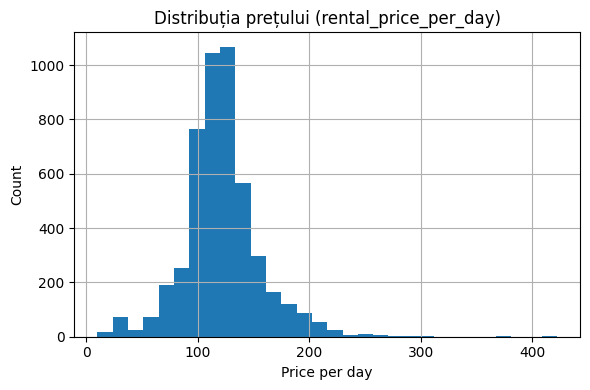

In [14]:
plt.figure(figsize=(6,4))
df["rental_price_per_day"].hist(bins=30)
plt.title("Distribuția prețului (rental_price_per_day)")
plt.xlabel("Price per day")
plt.ylabel("Count")
plt.tight_layout()
plt.show()


Kilometri

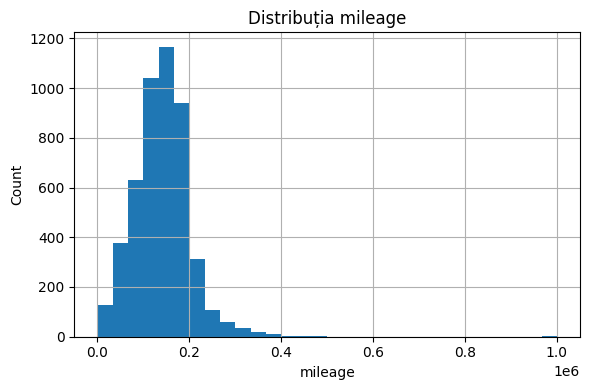

In [15]:
plt.figure(figsize=(6,4))
df["mileage"].hist(bins=30)
plt.title("Distribuția mileage")
plt.xlabel("mileage")
plt.ylabel("Count")
plt.tight_layout()
plt.show()


Pret vs Kilometri

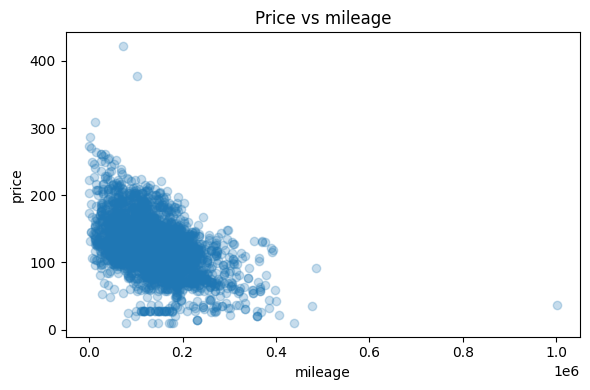

In [16]:
plt.figure(figsize=(6,4))
plt.scatter(df["mileage"], df["rental_price_per_day"], alpha=0.25)
plt.title("Price vs mileage")
plt.xlabel("mileage")
plt.ylabel("price")
plt.tight_layout()
plt.show()


Pret / categorie

<Figure size 800x400 with 0 Axes>

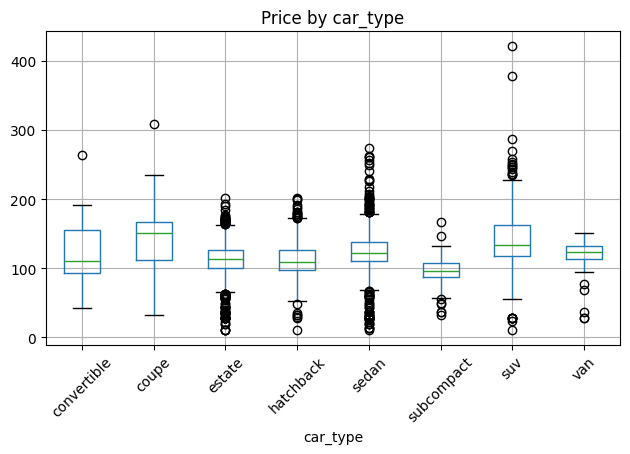

In [17]:
plt.figure(figsize=(8,4))
df.boxplot(column="rental_price_per_day", by="car_type")
plt.title("Price by car_type")
plt.suptitle("")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


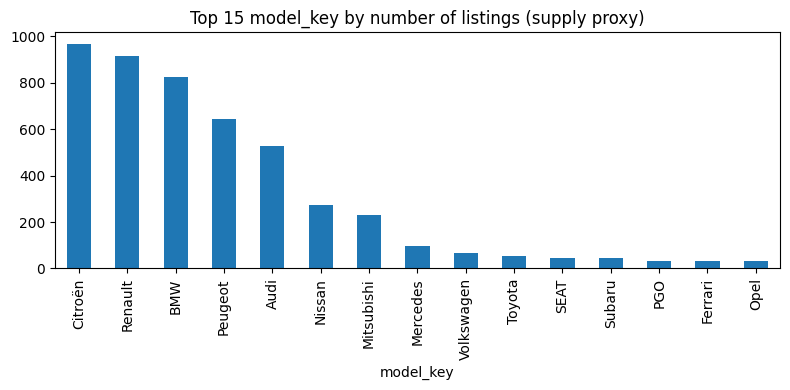

In [18]:
top_counts = df["model_key"].value_counts().head(15)
plt.figure(figsize=(8,4))
top_counts.plot(kind="bar")
plt.title("Top 15 model_key by number of listings (supply proxy)")
plt.tight_layout()
plt.show()


Distributia pretului (rental_price_per_day) este concentrata in zona ~80–150, dar are o coada spre valori mari, deci exista cateva masini/listari mult mai scumpe (outliere, peste 250–300).

mileage are o distributie asimetrica (multe valori in zona mica/medie si cateva foarte mari), iar in scatter se vede clar o tendinta: pe masura ce mileage creste, pretul tinde sa scada, dar relatia nu este perfect liniara (exista variatie mare la acelasi mileage).

Boxplot-ul arata diferente intre tipurile de masini: suv (si partial coupe/convertible) au in general preturi mai mari, in timp ce subcompact/hatchback/estate tind sa fie mai ieftine, cu outliere in aproape toate categoriile.

Graficul pe model_key indica o oferta foarte dezechilibrata: cateva branduri domina numarul de listari (piata “saturata”), iar multe altele apar rar (potential mai mare pentru “nise”, in functie de cerere si pret).

In [19]:
target = "rental_price_per_day"
y = df[target]
X = df.drop(columns=[target])

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [20]:
num_cols = X_train.select_dtypes(include=["int64","float64"]).columns.tolist()
cat_cols = X_train.select_dtypes(include=["object","bool"]).columns.tolist()

print("Numeric:", num_cols)
print("Categorical:", cat_cols)


Numeric: ['Unnamed: 0', 'mileage', 'engine_power']
Categorical: ['model_key', 'fuel', 'paint_color', 'car_type', 'private_parking_available', 'has_gps', 'has_air_conditioning', 'automatic_car', 'has_getaround_connect', 'has_speed_regulator', 'winter_tires']


In [21]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, num_cols),
        ("cat", categorical_transformer, cat_cols),
    ]
)


In [22]:
from sklearn.linear_model import Ridge
from sklearn.pipeline import Pipeline

ridge = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", Ridge())
])

ridge.fit(X_train, y_train)
pred_ridge = ridge.predict(X_test)


Model 1 (Ridge) + metrici + grafic

Ridge MAE:  12.117
Ridge RMSE: 17.970


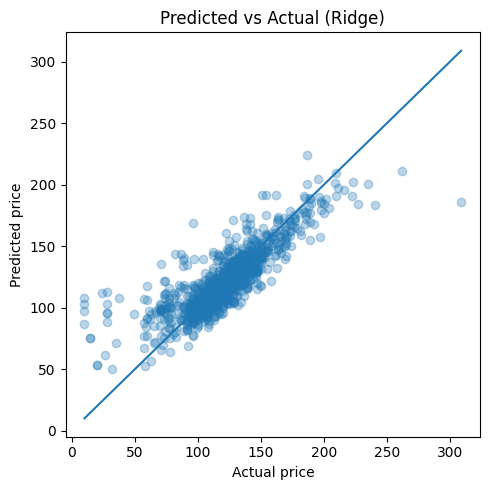

In [24]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
import matplotlib.pyplot as plt

mae = mean_absolute_error(y_test, pred_ridge)
mse = mean_squared_error(y_test, pred_ridge)
rmse = np.sqrt(mse)

print(f"Ridge MAE:  {mae:.3f}")
print(f"Ridge RMSE: {rmse:.3f}")

plt.figure(figsize=(5,5))
plt.scatter(y_test, pred_ridge, alpha=0.3)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()])
plt.title("Predicted vs Actual (Ridge)")
plt.xlabel("Actual price")
plt.ylabel("Predicted price")
plt.tight_layout()
plt.show()


Model 2 pentru regresie (RandomForestRegressor)

RF MAE:  10.740
RF RMSE: 16.941


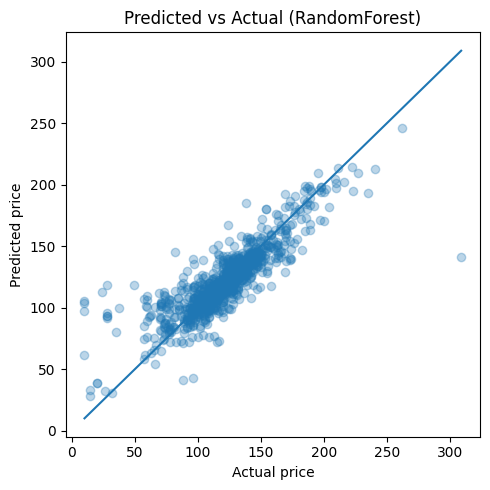

In [25]:
from sklearn.ensemble import RandomForestRegressor

rf_reg = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", RandomForestRegressor(
        n_estimators=300,
        random_state=42,
        n_jobs=-1
    ))
])

rf_reg.fit(X_train, y_train)
pred_rf = rf_reg.predict(X_test)

mae_rf = mean_absolute_error(y_test, pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, pred_rf))

print(f"RF MAE:  {mae_rf:.3f}")
print(f"RF RMSE: {rmse_rf:.3f}")

plt.figure(figsize=(5,5))
plt.scatter(y_test, pred_rf, alpha=0.3)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()])
plt.title("Predicted vs Actual (RandomForest)")
plt.xlabel("Actual price")
plt.ylabel("Predicted price")
plt.tight_layout()
plt.show()


RandomForest e mai bun decat Ridge pe acest dataset.

Interpretare rezultate

Ridge: MAE ≈ 12.117, RMSE ≈ 17.970

RandomForest: MAE ≈ 10.740, RMSE ≈ 16.941

Ce inseamna:

MAE (Mean Absolute Error) rezulta, in medie, cu cat greseste modelul la pret. La RandomForest, greseala medie e ~10.7 unitati (euro/zi).

RMSE penalizeaza mai mult greselile mari (outliere). RandomForest are RMSE mai mic, deci gestioneaza mai bine cazurile “grele”.

Graficul Predicted vs Actual:

Linia diagonala = “predictie perfecta”.

Majoritatea punctelor sunt destul de aproape de linie, deci modelul invata bine.

Se vede ca la preturi foarte mari exista cateva puncte mai indepartate (outliere), ceea ce e normal.

Concluzie:
“RandomForestRegressor obtine MAE si RMSE mai mici decat Ridge, deci il aleg ca model final pentru recomandarea pretului.”

**Model 2** (clasificare) care identifica categorii cu oferta mica + pret potential mare.

Pasul 1: Construim label-ul opportunity

In [26]:
df2 = df.copy()

# 1) supply proxy: cate listari sunt in fiecare model_key
df2["supply_count"] = df2.groupby("model_key")["model_key"].transform("count")

# 2) price potential: folosim predictia RandomForest (modelul tau de pret)
rf_reg.fit(X, y)  # refit pe tot dataset-ul, ca sa avem predictii pentru toate randurile
df2["pred_price"] = rf_reg.predict(X)

# 3) praguri (20% oferta mica, 30% pret mare)
supply_thr = df2["supply_count"].quantile(0.20)
price_thr = df2["pred_price"].quantile(0.70)

df2["opportunity"] = ((df2["supply_count"] <= supply_thr) & (df2["pred_price"] >= price_thr)).astype(int)

df2["opportunity"].value_counts()


,count
opportunity,
0,4063
1,780


In [27]:
from sklearn.model_selection import train_test_split

y_cls = df2["opportunity"]
X_cls = df2.drop(columns=["opportunity", "rental_price_per_day"])

Xc_train, Xc_test, yc_train, yc_test = train_test_split(
    X_cls, y_cls, test_size=0.2, random_state=42, stratify=y_cls
)

num_cols_c = Xc_train.select_dtypes(include=["int64","float64"]).columns.tolist()
cat_cols_c = Xc_train.select_dtypes(include=["object","bool"]).columns.tolist()

num_cols_c, cat_cols_c


(['Unnamed: 0', 'mileage', 'engine_power', 'supply_count', 'pred_price'],
 ['model_key',
  'fuel',
  'paint_color',
  'car_type',
  'private_parking_available',
  'has_gps',
  'has_air_conditioning',
  'automatic_car',
  'has_getaround_connect',
  'has_speed_regulator',
  'winter_tires'])

In [28]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

numeric_transformer_c = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer_c = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocess_c = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer_c, num_cols_c),
        ("cat", categorical_transformer_c, cat_cols_c),
    ]
)


Accuracy : 0.9866
Precision: 0.9613
Recall   : 0.9551
F1       : 0.9582

              precision    recall  f1-score   support

           0       0.99      0.99      0.99       813
           1       0.96      0.96      0.96       156

    accuracy                           0.99       969
   macro avg       0.98      0.97      0.98       969
weighted avg       0.99      0.99      0.99       969



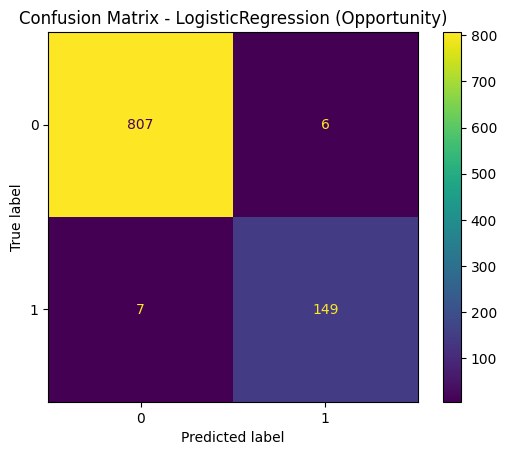

In [29]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay, classification_report
import matplotlib.pyplot as plt

log_cls = Pipeline(steps=[
    ("preprocess", preprocess_c),
    ("model", LogisticRegression(max_iter=2000))
])

log_cls.fit(Xc_train, yc_train)
pred_log = log_cls.predict(Xc_test)

acc = accuracy_score(yc_test, pred_log)
prec = precision_score(yc_test, pred_log, zero_division=0)
rec = recall_score(yc_test, pred_log, zero_division=0)
f1 = f1_score(yc_test, pred_log, zero_division=0)

print(f"Accuracy : {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall   : {rec:.4f}")
print(f"F1       : {f1:.4f}\n")
print(classification_report(yc_test, pred_log, zero_division=0))

cm = confusion_matrix(yc_test, pred_log)
ConfusionMatrixDisplay(cm).plot()
plt.title("Confusion Matrix - LogisticRegression (Opportunity)")
plt.show()


**Interpretare rezultate **
Metrici:

Accuracy = 0.9866 → ~98.7% din predictii sunt corecte.

Precision = 0.9613 (pentru clasa 1 = “opportunity”) → din toate cazurile prezise ca oportunitate, ~96% chiar sunt oportunitati.

Recall = 0.9551 → din oportunitatile reale, modelul gaseste ~95.5%.

F1 = 0.9582 → scor echilibrat intre precision si recall, foarte bun.

Confusion Matrix (cum se citeste):

TN (0 corect) = 807 (a zis “nu e oportunitate” si a avut dreptate)

FP = 6 (a zis “oportunitate”, dar nu era)

FN = 7 (a ratat cateva oportunitati)

TP (1 corect) = 149 (a gasit oportunitati corect)

Concluzie scurta pentru notebook :
“Modelul LogisticRegression identifica bine oportunitatile (F1 ~0.96) cu putine alarme false si putine oportunitati ratate.”

Markdown :

Pentru regresie (predictia pretului), aleg RandomForestRegressor deoarece are MAE si RMSE mai mici decat Ridge pe setul de test.

Pentru clasificare (opportunity), aleg LogisticRegression deoarece obtine scoruri foarte bune (Accuracy ~0.99, F1 ~0.96) si este usor de interpretat.

In [30]:
final_price_model = rf_reg
final_opportunity_model = log_cls


**Salvez modelele**

In [31]:
import joblib

joblib.dump(final_price_model, "price_model.pkl")
joblib.dump(final_opportunity_model, "opportunity_model.pkl")
print("Saved: price_model.pkl, opportunity_model.pkl")


Saved: price_model.pkl, opportunity_model.pkl


In [32]:
price_loaded = joblib.load("price_model.pkl")
opp_loaded = joblib.load("opportunity_model.pkl")

sample_price = X.iloc[:5]
sample_opp = X_cls.iloc[:5]

print("Predicted prices:", price_loaded.predict(sample_price))
print("Predicted opportunity:", opp_loaded.predict(sample_opp))


Predicted prices: [108.81666667 222.44       100.9        152.61       167.02666667]
Predicted opportunity: [0 0 0 0 0]


**Top oportunitati**

In [33]:
df_out = df2.copy()
df_out["opp_pred"] = final_opportunity_model.predict(X_cls)

top_ideas = (
    df_out[df_out["opp_pred"] == 1]
    .sort_values(["pred_price", "supply_count"], ascending=[False, True])
    .head(20)
)

top_ideas[["model_key", "car_type", "pred_price", "supply_count", "mileage", "engine_power", "fuel"]]


,model_key,car_type,pred_price,supply_count,mileage,engine_power,fuel
4753,BMW,suv,325.623333,827,72515,135,diesel
4684,SEAT,suv,285.526667,46,103222,140,diesel
4146,Suzuki,suv,267.843333,8,2970,423,petrol
4731,Toyota,suv,265.146667,53,4530,230,diesel
2938,Renault,sedan,264.940000,916,-64,230,diesel
3345,Maserati,sedan,259.746667,18,25571,235,diesel
3320,Maserati,sedan,259.646667,18,25858,235,diesel
3595,Maserati,sedan,255.363333,18,34624,235,diesel
90,Renault,coupe,252.750000,916,12402,170,hybrid_petrol
4749,Subaru,suv,252.256667,44,29460,280,diesel


**Acest tabel arata Top 20 oportunitati identificate de modelul de clasificare. opp_pred = 1 inseamna ca listing-ul apartine unei categorii cu oferta relativ mica (supply_count scazut) si pret potential mare (pred_price mare, estimat de modelul de regresie). Sortarea este facuta descrescator dupa pred_price si crescator dupa supply_count, pentru a prioritiza nisele cu venit potential ridicat si competitie mai mica.**

**Arat care categorii merita** (in 20 de randuri)

In [34]:
summary_by_model = (
    df_out[df_out["opp_pred"] == 1]
    .groupby("model_key")
    .agg(
        listings=("model_key", "count"),
        avg_pred_price=("pred_price", "mean"),
        min_supply=("supply_count", "min")
    )
    .sort_values(["avg_pred_price", "listings"], ascending=[False, False])
    .head(15)
)

summary_by_model

summary_by_type = (
    df_out[df_out["opp_pred"] == 1]
    .groupby("car_type")
    .agg(
        listings=("car_type", "count"),
        avg_pred_price=("pred_price", "mean"),
        min_supply=("supply_count", "min")
    )
    .sort_values(["avg_pred_price", "listings"], ascending=[False, False])
    .head(15)
)

summary_by_type

,listings,avg_pred_price,min_supply
model_key,,,
BMW,2,266.483333,827
Renault,2,258.845000,916
Peugeot,2,225.313333,642
Suzuki,8,216.135417,8
Mini,1,194.976667,1
Lexus,2,191.700000,2
Maserati,18,186.967593,18
Mitsubishi,195,181.832051,231
Subaru,43,180.408295,44


Asta e un rezumat pe brand (model_key) pentru toate randurile pe care modelul le-a marcat ca oportunitate (opp_pred = 1). Practic e un “mini-raport” business.

Ce inseamna coloanele

model_key: brandul / categoria (ex: BMW, Renault, Suzuki).

listings: cate listari din dataset au fost detectate ca oportunitate pentru acel brand.

mare = modelul gaseste multe exemple “bune” in dataset pentru brandul respectiv.

avg_pred_price: pretul mediu estimat de modelul de regresie pentru acele oportunitati.

mai mare = potential de venit mai bun (in medie).

min_supply: cea mai mica valoare de supply_count intalnita la oportunitatile acelui brand.

mai mic = exista cel putin o sub-nisa cu competitie foarte mica (putine listari).

BMW / Renault / Peugeot sunt sus pentru ca au pret estimat mare (avg_pred_price) in oportunitatile gasite.
Dar la ele min_supply e mare (827, 916, 642) ceea ce sugereaza ca brandul e destul de “prezent” in piata; deci oportunitatea vine mai mult din pret, nu neaparat din raritate.

Suzuki are 8 oportunitati si un min_supply foarte mic (8). Asta e interesant: inseamna ca exista o zona unde Suzuki e rar (competitie mica) si totusi modelul vede pret potential bun.

Mini (min_supply = 1) si Lexus (min_supply = 2) arata nise extrem de rare (aproape inexistente in dataset). Aici ai “oportunitate de nisa”, dar trebuie verificat in realitate daca exista cerere, nu doar lipsa de oferta.

Maserati (listings = 18) are multe oportunitati si pret destul de ridicat. Asta indica o zona premium unde modelul detecteaza potential bun.

Mitsubishi (listings = 195) are foarte multe oportunitati, dar min_supply 231 inseamna ca nu e chiar nisa. Poate e o categorie unde modelul “vede” pret bun relativ la feature-uri, dar competitia e moderata.

Rezumatul pe model_key arata ce branduri apar cel mai des in lista de oportunitati (listings), care au pret potential mai mare (avg_pred_price) si unde exista nise cu oferta mica (min_supply). De exemplu, Suzuki are min_supply foarte mic, sugerand o nisa cu competitie redusa, in timp ce BMW/Renault sunt mai sus prin pret estimat mare, dar cu oferta mai ridicata.

In [37]:
summary_by_type = (
    df_out[df_out["opp_pred"] == 1]
    .groupby("car_type")
    .agg(
        listings=("car_type", "count"),
        avg_pred_price=("pred_price", "mean"),
        min_supply=("supply_count", "min")
    )
    .sort_values(["avg_pred_price", "listings"], ascending=[False, False])
)
summary_by_type


,listings,avg_pred_price,min_supply
car_type,,,
coupe,1,252.750000,916
suv,322,181.953344,8
sedan,210,156.143762,1
subcompact,1,155.280000,6
hatchback,93,147.591720,2
estate,130,146.594872,33
van,12,141.416944,1


In [38]:
top_ideas.to_csv("top_opportunities.csv", index=False)
summary_by_model.to_csv("opportunity_summary_by_model_key.csv")
summary_by_type.to_csv("opportunity_summary_by_car_type.csv", index=True)
print("Saved CSVs.")


Saved CSVs.


**Ca sa pot folosi modelul ulterior fara sa il antrenez din nou**

In [39]:
import joblib

joblib.dump(final_price_model, "price_model.pkl")
joblib.dump(final_opportunity_model, "opportunity_model.pkl")
print("Saved models.")


Saved models.


**Arat ca pot incarca modelele si face predictii pe date noi**

In [40]:
price_loaded = joblib.load("price_model.pkl")
opp_loaded = joblib.load("opportunity_model.pkl")

# luam 3 exemple random
sample_idx = X.sample(3, random_state=42).index
x_price = X.loc[sample_idx]
x_opp = X_cls.loc[sample_idx]

print("Predicted prices:", price_loaded.predict(x_price))
print("Predicted opportunity:", opp_loaded.predict(x_opp))


Predicted prices: [147.50333333 116.42       155.58666667]
Predicted opportunity: [0 0 1]


**Organizez proiectul pentru livrare pe GitHub: results/ pentru CSV-uri, models/ pentru .pkl**

In [41]:
import os, shutil

os.makedirs("results", exist_ok=True)
os.makedirs("models", exist_ok=True)

# move CSVs to results/
for f in ["top_opportunities.csv",
          "opportunity_summary_by_model_key.csv",
          "opportunity_summary_by_car_type.csv"]:
    if os.path.exists(f):
        shutil.move(f, f"results/{f}")

# move models to models/
for f in ["price_model.pkl", "opportunity_model.pkl"]:
    if os.path.exists(f):
        shutil.move(f, f"models/{f}")

print("Moved files into results/ and models/")


Moved files into results/ and models/


**Ca proiectul sa ruleze la oricine cu pip install -r requirements.txt.**

In [42]:
req = """pandas
numpy
matplotlib
scikit-learn
joblib
"""
with open("requirements.txt", "w") as f:
    f.write(req)
print("requirements.txt saved")


requirements.txt saved


In [44]:
readme = """# Price Prediction + Opportunity Detection (ML End-to-End)

## Problema
Proiectul estimeaza pretul de inchiriere pe zi (regresie) si identifica oportunitati (clasificare) pentru nise cu oferta mica si pret potential mare.

## Dataset
- Sursa: HuggingFace dataset (car rental)
- Target regresie: rental_price_per_day
- Label clasificare: opportunity (definit heuristic: supply mic + pret estimat mare)

## Ce am facut
1. EDA (vizualizari + observatii)
2. Preprocesare (OneHot pentru categorice, StandardScaler pentru numerice)
3. Model 1 (Regresie): Ridge vs RandomForestRegressor (final: RandomForest)
4. Model 2 (Clasificare): LogisticRegression pentru opportunity + Confusion Matrix
5. Export rezultate (CSV) si salvare modele (PKL)

## Rezultate
- Regresie:
  - Ridge: MAE=12.117, RMSE=17.970
  - RandomForest: MAE=10.740, RMSE=16.941 (model final)
- Clasificare (Opportunity, LogisticRegression):
  - Accuracy=0.9866, Precision=0.9613, Recall=0.9551, F1=0.9582

## Cum rulezi
pip install -r requirements.txt
Ruleaza notebook-ul in Google Colab / Jupyter.

## Fisiere generate
- models/price_model.pkl
- models/opportunity_model.pkl
- results/top_opportunities.csv
- results/opportunity_summary_by_model_key.csv
- results/opportunity_summary_by_car_type.csv
"""
with open("README.md", "w") as f:
    f.write(readme)
print("README.md saved")


README.md saved


In [45]:
import os

for root, dirs, files in os.walk("."):
    if root.startswith("./."):
        continue
    print(root)
    for f in files:
        print("  -", f)


.
  - README.md
  - requirements.txt
./models
  - opportunity_model.pkl
  - price_model.pkl
./results
  - opportunity_summary_by_model_key.csv
  - opportunity_summary_by_car_type.csv
  - top_opportunities.csv
./sample_data
  - README.md
  - anscombe.json
  - mnist_train_small.csv
  - mnist_test.csv
  - california_housing_test.csv
  - california_housing_train.csv


**Pastrez repo-ul curat, doar fisierele relevante pentru proiect.**

In [46]:
import shutil, os

if os.path.exists("sample_data"):
    shutil.rmtree("sample_data")
    print("sample_data deleted")
else:
    print("sample_data not found")


sample_data deleted


**Creez un singur fisier (zip) usor de descarcat si incarcat pe GitHub**

In [47]:
import shutil

shutil.make_archive("ml_project", "zip", ".")
print("Created ml_project.zip")


Created ml_project.zip
